# Phase 1 main experiment (part 1c): does SHAP localization beat a label-free KS test?

**The threat.** Notebook 07b reframed the contribution to auxiliary-model SHAP
localization. But Q008 showed input-distribution drift (KS) and importance drift
(oracle SHAP) agree at Jaccard 0.68-0.77 on the drift days. If a **label-free,
model-free KS test** on the inputs localizes the drifted features as well as the
SHAP pipeline (aux model + TreeSHAP), then the entire explanation apparatus is
redundant for localization, and the thesis's sharpest claimed distinction --
importance drift is not the same as input drift -- is barely exercised on
CICIDS. This notebook tests that directly.

**The circularity trap, and how we avoid it.** In nb07/07b, GT1 was *defined* as
the KS-top-15 set, so scoring KS against GT1 gives a meaningless ~1.0. A fair
arbiter must be independent of both KS and aux-SHAP. We use two:

- **GT2 (attribution):** oracle SHAP importance top-15 -- what a privileged model
  attributes its attack detection to. SHAP-modality, so it mildly favours aux.
- **GT3 (behaviour, the neutral judge):** oracle *permutation* importance top-15
  -- which features, when shuffled, most hurt the oracle's recall on the day's
  attacks. This is model-behaviour, independent of SHAP attribution and of KS.

If aux-SHAP beats KS only against GT2 but ties against GT3, the edge is just
"SHAP predicts SHAP" and KS is genuinely redundant. **GT3 is the honest judge.**

**Methods compared (per-feature localization scores):**

| Name | Needs | Score |
|---|---|---|
| `ks` | nothing but inputs (no labels, no model, no SHAP) | KS-D(Monday vs day) per feature |
| `aux_only` | labels + aux model + SHAP | auxiliary SHAP importance |
| `dual_gain` | + frozen model | relu(imp_aux - imp_main) |
| `perm_disagree` | labels + both models | permutation-disagreement |
| `random` | nothing | uniform |

The aux model is given its **strongest** form (100k labels) -- if SHAP cannot
beat a free KS test even at maximal supervision, the redundancy is decisive.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score

from src.data.loaders import load_cicids2017
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, permutation_disagreement_importance, ks_drift_scores,
    topk_indices, precision_at_k, recall_at_k, jaccard,
    random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
CHECKPOINTS = ROOT / 'experiments' / 'checkpoints'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase1_07c_ks_vs_shap.json'
for p in (FIGURES, TABLES, CHECKPOINTS):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
FEATURE_COLS = meta06['feature_columns']
CONSTANT_FEATURES = meta06['constant_features_dropped']
RF_PARAMS = meta06['rf_hyperparameters']
N_FEATURES = len(FEATURE_COLS)

rf_cold = joblib.load(meta06['models']['cold_start'])
rf_oracle = joblib.load(meta06['models']['oracle'])
print(f'Loaded cold_start and oracle. {N_FEATURES} features.')

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)

METHOD_COLOR = {
    'ks': '#0072B2', 'aux_only': '#E69F00', 'dual_gain': '#009E73',
    'perm_disagree': '#D55E00', 'main_only': '#999999', 'random': '#000000',
}
METHOD_LABEL = {
    'ks': 'KS (label-free)', 'aux_only': 'Aux-SHAP', 'dual_gain': 'Dual-gain',
    'perm_disagree': 'Perm-disagree', 'main_only': 'Main-only', 'random': 'Random',
}
GT_LABEL = {'GT1': 'GT1 KS (circular for KS)', 'GT2': 'GT2 oracle SHAP',
            'GT3': 'GT3 oracle permutation (neutral)'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='07c_ks_vs_shap_localization'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')


Mounted at /content/drive
Loaded cold_start and oracle. 82 features.
Setup complete.


## 2. D019 -- the redundancy test and its pre-registered decision rule

In [2]:
log_decision(
    decision_id='D019',
    decision=(
        'Add KS-drift as a label-free, model-free localization METHOD and test '
        'whether SHAP-based localization (aux_only) beats it. Compare against '
        'three ground truths: GT1 (KS, circular for KS, shown only for '
        'transparency), GT2 (oracle SHAP importance, attribution), and GT3 '
        '(oracle permutation importance w.r.t. attack recall, behaviour -- the '
        'neutral arbiter independent of both KS and SHAP). Aux model given its '
        'strongest form (100k labels). Pre-registered rule, committed before '
        'execution: the explanation pipeline EARNS ITS PLACE iff aux_only beats '
        'ks by >= 0.10 post-drift mean precision@10 against GT3, exceeding one '
        'standard error above zero. If the GT3 margin is within +/-0.10 '
        '(REDUNDANT), a label-free KS test localizes as well as SHAP and the '
        'explanation machinery is redundant for localization on CICIDS. If ks '
        'beats aux_only (KS-BETTER), worse still. GT2 and the direct mutual '
        'Jaccard(ks, aux) are reported as supporting evidence but GT3 decides.'
    ),
    rationale=(
        'Q008 (GT1/GT2 Jaccard 0.68-0.77) raised that input-drift and '
        'importance-drift largely coincide on CICIDS, threatening the whole '
        'localization spine, not just the dual variant. Comparing KS against a '
        'SHAP-modality ground truth (GT2) would unfairly favour SHAP; GT3 '
        '(behaviour-based) breaks that circularity. Giving aux 100k labels makes '
        'any redundancy finding maximally conservative.'
    ),
    alternatives=(
        'Judge on GT2 only (rejected: SHAP-modality favours aux). Judge on GT1 '
        '(rejected: circular for KS). Lower aux budgets (unnecessary: nb07b '
        'showed aux is budget-insensitive here).'
    ),
)


[DECISION LOGGED] D019


## 3. Configuration

In [3]:
DAYS = ['tuesday', 'wednesday', 'thursday', 'friday']
CONTROL_DAY = 'tuesday'
POST_DRIFT_DAYS = ['wednesday', 'thursday', 'friday']

K_PRIMARY = 10
K_SWEEP = [5, 10, 20]
GT_SIZE = 15
SHAP_SAMPLE = 2000
KS_SAMPLE = 20000
AUX_TRAIN_FRAC = 0.6
AUX_BUDGET = 100000          # give SHAP its strongest form
SEEDS = [42, 1, 7]
PERM_REPEATS = 5             # for the GT3 oracle permutation importance

ALL_METHODS = ['ks', 'aux_only', 'dual_gain', 'perm_disagree', 'main_only', 'random']
HEADLINE_METHODS = ['ks', 'aux_only', 'dual_gain', 'random']
GT_NAMES = ['GT1', 'GT2', 'GT3']
PRIMARY_GT = 'GT3'
REDUNDANCY_MARGIN = 0.10
RANDOM_EXPECT = random_precision_expectation(GT_SIZE, N_FEATURES)

print(f'Primary arbiter: {PRIMARY_GT} (oracle permutation importance).')
print(f'SHAP earns its place iff aux_only - ks >= +{REDUNDANCY_MARGIN} vs {PRIMARY_GT} (post-drift).')
print(f'Random precision@K = {RANDOM_EXPECT:.3f}  |  aux budget = {AUX_BUDGET:,}  |  seeds {SEEDS}')


Primary arbiter: GT3 (oracle permutation importance).
SHAP earns its place iff aux_only - ks >= +0.1 vs GT3 (post-drift).
Random precision@K = 0.183  |  aux budget = 100,000  |  seeds [42, 1, 7]


## 4. Helpers

In [4]:
def stratified_sample(X, y, n, seed):
    n = min(n, len(y))
    if y.nunique() < 2 or n >= len(y):
        idx = np.random.default_rng(seed).choice(len(y), size=n, replace=False)
        return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)
    idx, _ = train_test_split(np.arange(len(y)), train_size=n, stratify=y, random_state=seed)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


def train_or_load_aux(day, budget, seed, X_tr, y_tr):
    ckpt = CHECKPOINTS / f'rf_aux_{day}_b{budget}_s{seed}.joblib'   # reuses nb07b cache
    if ckpt.exists():
        return joblib.load(ckpt)
    rf = RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed}).fit(X_tr, y_tr)
    joblib.dump(rf, ckpt)
    return rf


def load_day(day):
    X, y, meta = load_cicids2017(day=day)
    X = X.drop(columns=CONSTANT_FEATURES, errors='ignore')[FEATURE_COLS]
    return X, y, meta


def oracle_permutation_importance(model, X, y, n_repeats=PERM_REPEATS, seed=42):
    """Per-feature drop in the model's attack-recall when the feature is shuffled.
    A SHAP-independent, behaviour-based measure of 'what the oracle relies on'."""
    r = permutation_importance(model, X, y, scoring='recall',
                               n_repeats=n_repeats, random_state=seed, n_jobs=-1)
    return r.importances_mean

print('Helpers defined.')


Helpers defined.


## 5. Build the three ground truths (deterministic per day, seed 42)

In [5]:
X_mon, y_mon, _ = load_day('monday')
mon_X, _ = stratified_sample(X_mon, y_mon, KS_SAMPLE, seed=42)

ground_truth = {}
gt_overlap_rows = []
for day in DAYS:
    Xd, yd, _ = load_day(day)
    # KS scores (also a METHOD, kept as a vector)
    day_ks_X, _ = stratified_sample(Xd, yd, KS_SAMPLE, seed=42)
    ks = ks_drift_scores(mon_X, day_ks_X)
    gt1 = topk_indices(ks, GT_SIZE)
    # fixed eval sample of this day
    _, ev_idx = train_test_split(np.arange(len(yd)), train_size=AUX_TRAIN_FRAC,
                                 stratify=yd if yd.nunique() > 1 else None, random_state=42)
    Xev42 = Xd.iloc[ev_idx].reset_index(drop=True)
    yev42 = yd.iloc[ev_idx].reset_index(drop=True)
    Xs42, ys42 = stratified_sample(Xev42, yev42, SHAP_SAMPLE, seed=42)
    # GT2 attribution, GT3 behaviour
    gt2 = topk_indices(shap_importance(rf_oracle, Xs42), GT_SIZE)
    perm_imp = (oracle_permutation_importance(rf_oracle, Xs42, ys42)
                if ys42.nunique() > 1 else np.zeros(N_FEATURES))
    gt3 = topk_indices(perm_imp, GT_SIZE)
    ground_truth[day] = {'GT1': gt1, 'GT2': gt2, 'GT3': gt3, 'ks': ks}
    gt_overlap_rows.append({
        'day': day,
        'J(GT1,GT2)': jaccard(gt1, gt2), 'J(GT1,GT3)': jaccard(gt1, gt3),
        'J(GT2,GT3)': jaccard(gt2, gt3), 'max_ks': float(np.max(ks)),
    })
    print(f'{day:<10} J(KS,SHAP)={jaccard(gt1, gt2):.2f}  J(KS,perm)={jaccard(gt1, gt3):.2f}  '
          f'J(SHAP,perm)={jaccard(gt2, gt3):.2f}')

gt_overlap_df = pd.DataFrame(gt_overlap_rows)
print('\nGround-truth overlaps (Jaccard, sets of 15):')
print(gt_overlap_df.round(3).to_string(index=False))


tuesday    J(KS,SHAP)=0.43  J(KS,perm)=0.30  J(SHAP,perm)=0.20
wednesday  J(KS,SHAP)=0.76  J(KS,perm)=0.20  J(SHAP,perm)=0.20
thursday   J(KS,SHAP)=0.50  J(KS,perm)=0.15  J(SHAP,perm)=0.11
friday     J(KS,SHAP)=0.76  J(KS,perm)=0.20  J(SHAP,perm)=0.20

Ground-truth overlaps (Jaccard, sets of 15):
      day  J(GT1,GT2)  J(GT1,GT3)  J(GT2,GT3)  max_ks
  tuesday       0.429       0.304       0.200   0.076
wednesday       0.765       0.200       0.200   0.333
 thursday       0.500       0.154       0.111   0.210
   friday       0.765       0.200       0.200   0.456


## 6. Comparison loop

KS is per-day (deterministic, no labels), so it has no seed variance; the
SHAP-based methods vary by seed via the aux model and eval sample. We also
record the direct mutual overlap between KS's and aux-SHAP's top-K -- the
modality-neutral redundancy measure.


In [6]:
rows = []
mutual = []
t_start = time.time()

for day in DAYS:
    Xd, yd, _ = load_day(day)
    gts = {g: ground_truth[day][g] for g in GT_NAMES}
    ks_vec = ground_truth[day]['ks']

    for seed in SEEDS:
        tr_idx, ev_idx = train_test_split(
            np.arange(len(yd)), train_size=AUX_TRAIN_FRAC,
            stratify=yd if yd.nunique() > 1 else None, random_state=seed)
        Xtr_full = Xd.iloc[tr_idx].reset_index(drop=True)
        ytr_full = yd.iloc[tr_idx].reset_index(drop=True)
        Xev = Xd.iloc[ev_idx].reset_index(drop=True)
        yev = yd.iloc[ev_idx].reset_index(drop=True)

        Xtr_s, ytr_s = stratified_sample(Xtr_full, ytr_full, AUX_BUDGET, seed)
        aux = train_or_load_aux(day, AUX_BUDGET, seed, Xtr_s, ytr_s)
        Xs, ys = stratified_sample(Xev, yev, SHAP_SAMPLE, seed)

        imp_main = shap_importance(rf_cold, Xs)
        imp_aux = shap_importance(aux, Xs)
        perm = permutation_disagreement_importance(rf_cold, aux, Xs, seed=seed)
        scores = {
            'ks': ks_vec,
            'aux_only': imp_aux,
            'dual_gain': np.clip(imp_aux - imp_main, 0, None),
            'perm_disagree': perm,
            'main_only': imp_main,
            'random': np.random.default_rng(seed).random(N_FEATURES),
        }
        # direct redundancy: do KS and aux-SHAP pick the same top-K?
        mutual.append({'day': day, 'seed': seed,
                       'jaccard_ks_aux': jaccard(topk_indices(ks_vec, K_PRIMARY),
                                                 topk_indices(imp_aux, K_PRIMARY))})
        for mname, sc in scores.items():
            for gtn in GT_NAMES:
                for k in K_SWEEP:
                    rows.append({'day': day, 'seed': seed, 'method': mname,
                                 'gt': gtn, 'k': k,
                                 'precision': precision_at_k(sc, gts[gtn], k),
                                 'recall': recall_at_k(sc, gts[gtn], k)})
    print(f'{day:<10} done  ({time.time()-t_start:.0f}s elapsed)')

res = pd.DataFrame(rows)
mutual_df = pd.DataFrame(mutual)
res.to_csv(TABLES / '07c_ks_vs_shap_raw.csv', index=False)
print(f'\n{len(res)} rows.')


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

tuesday    done  (34s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

wednesday  done  (91s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

thursday   done  (149s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

friday     done  (203s elapsed)

648 rows.


## 7. Aggregate

In [7]:
def pmean(method, gtn, days=POST_DRIFT_DAYS, k=K_PRIMARY):
    s = res[(res['method'] == method) & (res['gt'] == gtn)
            & (res['k'] == k) & (res['day'].isin(days))]
    return float(s['precision'].mean()), float(s['precision'].std())

for gtn in GT_NAMES:
    tbl = pd.DataFrame({m: {d: res[(res['method'] == m) & (res['gt'] == gtn)
                                   & (res['k'] == K_PRIMARY) & (res['day'] == d)]['precision'].mean()
                            for d in DAYS} for m in ALL_METHODS}).T[DAYS].round(3)
    print(f'Precision@{K_PRIMARY} vs {GT_LABEL[gtn]} (rows=method, cols=day):\n')
    print(tbl.to_string()); print()
    tbl.to_csv(TABLES / f'07c_precision_{gtn}.csv')

mut = mutual_df[mutual_df['day'].isin(POST_DRIFT_DAYS)].groupby('day')['jaccard_ks_aux'].mean()
print('Mutual Jaccard(KS-top10, aux-top10) per post-drift day (1.0 = identical picks):')
print(mut.round(3).to_string())
print(f'  post-drift mean = {mut.mean():.3f}')


Precision@10 vs GT1 KS (circular for KS) (rows=method, cols=day):

               tuesday  wednesday  thursday  friday
ks               1.000      1.000     1.000   1.000
aux_only         0.200      1.000     0.500   0.633
dual_gain        0.000      1.000     0.400   0.600
perm_disagree    0.367      0.333     0.367   0.433
main_only        0.200      0.300     0.300   0.200
random           0.133      0.167     0.167   0.200

Precision@10 vs GT2 oracle SHAP (rows=method, cols=day):

               tuesday  wednesday  thursday  friday
ks               0.600      0.900     0.700   0.900
aux_only         0.200      0.933     0.733   0.633
dual_gain        0.100      0.900     0.633   0.600
perm_disagree    0.300      0.300     0.367   0.433
main_only        0.100      0.200     0.100   0.300
random           0.167      0.167     0.167   0.167

Precision@10 vs GT3 oracle permutation (neutral) (rows=method, cols=day):

               tuesday  wednesday  thursday  friday
ks               0

## 8. Figures

  saved: 07c_ks_vs_shap_gt3.png / .pdf


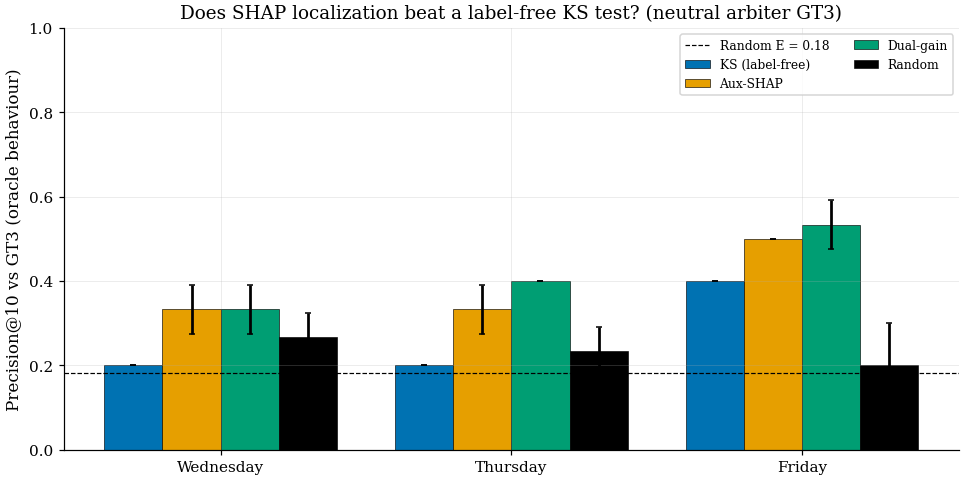

In [8]:
# ----- Figure 1: precision@10 vs GT3 (neutral arbiter) by method, post-drift -----
fig, ax = plt.subplots(figsize=(9, 4.6))
x = np.arange(len(POST_DRIFT_DAYS)); w = 0.2
for i, m in enumerate(HEADLINE_METHODS):
    means = [res[(res['method'] == m) & (res['gt'] == 'GT3') & (res['k'] == K_PRIMARY)
                 & (res['day'] == d)]['precision'].mean() for d in POST_DRIFT_DAYS]
    stds = [res[(res['method'] == m) & (res['gt'] == 'GT3') & (res['k'] == K_PRIMARY)
                & (res['day'] == d)]['precision'].std() for d in POST_DRIFT_DAYS]
    ax.bar(x + (i - 1.5) * w, means, w, yerr=stds, capsize=2, color=METHOD_COLOR[m],
           label=METHOD_LABEL[m], edgecolor='black', linewidth=0.4)
ax.axhline(RANDOM_EXPECT, ls='--', color='black', lw=0.8, label=f'Random E = {RANDOM_EXPECT:.2f}')
ax.set_xticks(x); ax.set_xticklabels([d.capitalize() for d in POST_DRIFT_DAYS])
ax.set_ylabel(f'Precision@{K_PRIMARY} vs GT3 (oracle behaviour)')
ax.set_ylim(0, 1.0)
ax.set_title('Does SHAP localization beat a label-free KS test? (neutral arbiter GT3)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); save_figure(fig, '07c_ks_vs_shap_gt3'); plt.show()


  saved: 07c_gt_comparison_and_redundancy.png / .pdf


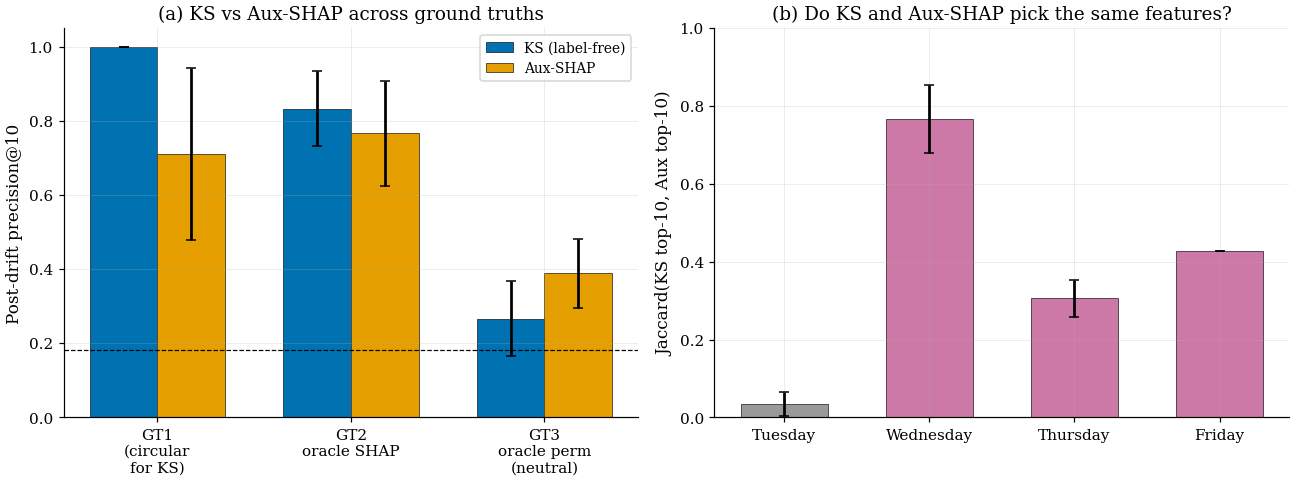

In [9]:
# ----- Figure 2: (a) ks vs aux across the 3 GTs   (b) mutual redundancy -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
x = np.arange(len(GT_NAMES)); w = 0.35
for i, m in enumerate(['ks', 'aux_only']):
    means = [pmean(m, g)[0] for g in GT_NAMES]
    errs = [pmean(m, g)[1] for g in GT_NAMES]
    ax.bar(x + (i - 0.5) * w, means, w, yerr=errs, capsize=3, color=METHOD_COLOR[m],
           label=METHOD_LABEL[m], edgecolor='black', linewidth=0.4)
ax.axhline(RANDOM_EXPECT, ls='--', color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(['GT1\n(circular\nfor KS)', 'GT2\noracle SHAP',
                                      'GT3\noracle perm\n(neutral)'])
ax.set_ylabel(f'Post-drift precision@{K_PRIMARY}'); ax.set_ylim(0, 1.05)
ax.set_title('(a) KS vs Aux-SHAP across ground truths')
ax.legend(fontsize=9)

ax = axes[1]
mj = mutual_df.groupby('day')['jaccard_ks_aux'].agg(['mean', 'std']).reindex(DAYS)
bar_c = ['#999999' if d == CONTROL_DAY else '#CC79A7' for d in DAYS]
ax.bar(range(len(DAYS)), mj['mean'], 0.6, yerr=mj['std'], capsize=3,
       color=bar_c, edgecolor='black', linewidth=0.4)
ax.set_xticks(range(len(DAYS))); ax.set_xticklabels([d.capitalize() for d in DAYS])
ax.set_ylabel('Jaccard(KS top-10, Aux top-10)'); ax.set_ylim(0, 1.0)
ax.set_title('(b) Do KS and Aux-SHAP pick the same features?')
fig.tight_layout(); save_figure(fig, '07c_gt_comparison_and_redundancy'); plt.show()


## 9. Pre-registered verdict (D019)

GT3 (oracle behaviour) decides. GT2 and mutual Jaccard are supporting context.


In [10]:
aux_gt3_m, aux_gt3_s = pmean('aux_only', 'GT3')
ks_gt3_m, ks_gt3_s = pmean('ks', 'GT3')
margin_gt3 = aux_gt3_m - ks_gt3_m
margin_gt3_se = np.sqrt(aux_gt3_s**2 + ks_gt3_s**2) / np.sqrt(len(SEEDS))

aux_gt2_m, _ = pmean('aux_only', 'GT2')
ks_gt2_m, _ = pmean('ks', 'GT2')
margin_gt2 = aux_gt2_m - ks_gt2_m
mutual_mean = float(mutual_df[mutual_df['day'].isin(POST_DRIFT_DAYS)]['jaccard_ks_aux'].mean())

if margin_gt3 >= REDUNDANCY_MARGIN and (margin_gt3 - margin_gt3_se) > 0:
    verdict = 'SHAP-ADDS-VALUE'
elif margin_gt3 <= -REDUNDANCY_MARGIN:
    verdict = 'KS-BETTER'
else:
    verdict = 'REDUNDANT'

print('=' * 64)
print('REDUNDANCY VERDICT (D019)  -- post-drift mean precision@%d' % K_PRIMARY)
print('=' * 64)
print(f'  vs GT3 (neutral): aux_only={aux_gt3_m:.3f}  ks={ks_gt3_m:.3f}  '
      f'margin={margin_gt3:+.3f} (SE {margin_gt3_se:.3f})')
print(f'  vs GT2 (SHAP)   : aux_only={aux_gt2_m:.3f}  ks={ks_gt2_m:.3f}  margin={margin_gt2:+.3f}')
print(f'  mutual Jaccard(KS, aux) post-drift = {mutual_mean:.3f}')
print(f'  random expectation = {RANDOM_EXPECT:.3f}')
print(f'\n--> VERDICT: {verdict}')
if verdict == 'SHAP-ADDS-VALUE':
    print('    SHAP localization captures detection-relevant features KS misses; explanation earns its place.')
elif verdict == 'KS-BETTER':
    print('    A free KS test localizes BETTER than SHAP; the explanation pipeline is not just redundant but inferior.')
else:
    print('    A label-free KS test localizes as well as SHAP; the explanation machinery is redundant for localization.')


REDUNDANCY VERDICT (D019)  -- post-drift mean precision@10
  vs GT3 (neutral): aux_only=0.389  ks=0.267  margin=+0.122 (SE 0.079)
  vs GT2 (SHAP)   : aux_only=0.767  ks=0.833  margin=-0.067
  mutual Jaccard(KS, aux) post-drift = 0.501
  random expectation = 0.183

--> VERDICT: SHAP-ADDS-VALUE
    SHAP localization captures detection-relevant features KS misses; explanation earns its place.


## 10. Record to the project log

In [11]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'aux_budget': AUX_BUDGET, 'seeds': SEEDS, 'k_primary': K_PRIMARY,
    'random_expectation': RANDOM_EXPECT, 'primary_gt': PRIMARY_GT,
    'aux_only_vs_gt3': aux_gt3_m, 'ks_vs_gt3': ks_gt3_m, 'margin_gt3': margin_gt3,
    'aux_only_vs_gt2': aux_gt2_m, 'ks_vs_gt2': ks_gt2_m, 'margin_gt2': margin_gt2,
    'mutual_jaccard_ks_aux_postdrift': mutual_mean,
    'gt_overlaps': gt_overlap_df.to_dict(orient='records'),
    'verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F007',
    title='Label-free KS vs SHAP localization on CICIDS2017 (notebook 07c)',
    context='03_phase1_cicids/07c_ks_vs_shap_localization',
    what_we_did=(
        'Added KS-drift as a label-free, model-free localization method and '
        'compared it to auxiliary SHAP importance (aux at 100k labels, its '
        'strongest form) against three ground truths: GT1 (KS, circular), GT2 '
        '(oracle SHAP), and GT3 (oracle permutation importance w.r.t. recall, '
        'the SHAP-independent neutral arbiter). Pre-registered rule (D019).'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. Post-drift precision@10 vs GT3 (neutral): '
        f'aux_only={aux_gt3_m:.3f} vs ks={ks_gt3_m:.3f} (margin {margin_gt3:+.3f}, '
        f'SE {margin_gt3_se:.3f}). vs GT2 (SHAP-modality): aux_only={aux_gt2_m:.3f} '
        f'vs ks={ks_gt2_m:.3f} (margin {margin_gt2:+.3f}). Mutual Jaccard(KS, aux) '
        f'post-drift = {mutual_mean:.3f}.'
    ),
    why_it_matters=(
        'Decides whether the explanation pipeline earns its place at all. If a '
        'free KS test localizes as well as SHAP against a behaviour-based ground '
        'truth, the localization contribution is redundant on CICIDS and the '
        'thesis must move its centre of gravity (adaptation-efficiency, a '
        'pure-concept-drift testbed, or a negative-empirical-study).'
    ),
)
print('F007 logged. Record the thesis-direction call in a hand journal entry.')


Saved /content/drive/MyDrive/phd_thesis/data/processed/phase1_07c_ks_vs_shap.json
[FINDING LOGGED] F007: Label-free KS vs SHAP localization on CICIDS2017 (notebook 07c)
F007 logged. Record the thesis-direction call in a hand journal entry.


## 11. What this settles

- **SHAP-ADDS-VALUE** -> the explanation pipeline finds detection-relevant
  features a label-free KS test misses. The localization spine holds; proceed to
  the adaptation experiment (nb08) with aux-only localization driving the
  retraining trigger.
- **REDUNDANT** -> a free KS test localizes as well as SHAP. The explanation
  machinery is not pulling its weight for *localization* on CICIDS. Two honest
  moves: (a) shift the contribution to adaptation-efficiency, where the value is
  "localized retraining beats naive retraining" regardless of whether KS or SHAP
  localizes; or (b) lean into the empirical/negative study -- drift-dominant
  failure, dual adds nothing, and explanation localization is redundant with a
  trivial input-statistics test on real IDS data.
- **KS-BETTER** -> as REDUNDANT, but sharper: the cheap test is also more
  accurate; the explanation approach is actively the wrong tool here.

In every branch, the case where explanations *should* dominate -- pure concept
drift with a stable input distribution -- is barely present in CICIDS day-stream
(new attacks change P(X), which KS catches). That points Phase 2/3 toward a
testbed that actually exhibits importance drift without input drift.

Record the decision by hand:

```python
add_journal_entry(
    title='Notebook 07c KS-vs-SHAP verdict and the thesis-direction call',
    body='...the GT3 margin, whether SHAP earns its place, and the chosen path...',
)
```
